In [340]:
# color="#1ca39c" - green
# color="#ffad00" - yellow

In [496]:
import pandas as pd
from  pathlib import Path
import importlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Datasets
- Client Profiles (df_final_demo): Demographics like age, gender, and account details of our clients.
- Digital Footprints (df_final_web_data): A detailed trace of client interactions online, divided into two parts: pt_1 and pt_2.
- Experiment Roster (df_final_experiment_clients): A list revealing which clients were part of the grand experiment.
- Project Phases & Tasks

In [497]:
demo = pd.read_csv(r"C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_Vanguard\df_final_demo.csv.txt")
experiment = pd.read_csv(r"C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_Vanguard\df_final_experiment_clients.csv.txt")
web_pt1 = pd.read_csv(r"C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_Vanguard\df_final_web_data_pt_1.csv.txt")
web_pt2 = pd.read_csv(r"C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_Vanguard\df_final_web_data_pt_2.csv.txt")

web = pd.concat([web_pt1, web_pt2], ignore_index=True)

In [451]:
demo.head()


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,55-64
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,55-64
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,18-34
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,45-54
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,18-34


In [319]:
demo["client_id"].nunique()

70609

In [498]:
experiment.rename(columns={"Variation": "variation"}, inplace=True)

In [475]:
experiment.head()

,client_id,variation,variation
0,9988021,Test,Test
1,8320017,Test,Test
2,4033851,Control,Control
3,1982004,Test,Test
4,9294070,Control,Control


In [321]:
experiment["client_id"].nunique()

70609

In [433]:
# Count Null values in experiment dataset
print("Null counts:")
print(experiment.isnull().sum())
print(f"\nNull percentages:")
print((experiment.isnull().sum() / len(experiment) * 100).round(1))

Null counts:
client_id        0
Variation    20109
dtype: int64

Null percentages:
client_id     0.0
Variation    28.5
dtype: float64


In [438]:
# Count Null values in web dataset
print("Null counts:")
print(web.isnull().sum())
print(f"\nNull percentages:")
print((web.isnull().sum() / len(web) * 100).round(1))

Null counts:
client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
step_num        0
duration        0
duration_min    0
dtype: int64

Null percentages:
client_id       0.0
visitor_id      0.0
visit_id        0.0
process_step    0.0
date_time       0.0
step_num        0.0
duration        0.0
duration_min    0.0
dtype: float64


In [407]:
#Check the number of common client_id in demo and experiment datasets:
common = demo.merge(experiment, on="client_id")
common["client_id"].nunique()

70609

In [ ]:
#Check the number of common client_id in experiment  & webdatasets:
common = web.merge(experiment, on="client_id")
common["client_id"].nunique()

70609

In [322]:
web.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [500]:
# Replace step_1, step_2 etc. by numbers:
mapping = {
    "start": 1,
    "step_1": 2,
    "step_2": 3,
    "step_3": 4,
    "confirm": 5
}

web["step_num"] = web["process_step"].map(mapping)
web.head(3)

,client_id,visitor_id,visit_id,process_step,date_time,step_num
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,4
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,3
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,4


In [501]:
# This ensures the date_time column is in proper datetime format (not strings)
web["date_time"] = pd.to_datetime(web["date_time"])
web = web.sort_values(["client_id", "visit_id", "date_time"])

# This orders events chronologically per user and visit.
# 1).diff() - Computes difference between current row and previous row
# 2) .shift(-1) - Moves values up one row: now each step shows time until the NEXT step (not time since the previous one)
web["duration"] = web.groupby(["client_id", "visit_id"])["date_time"].diff().shift(-1)
# Converts time differences into minutes (float)
web["duration_min"] = web["duration"].dt.total_seconds() / 60

# Remove steps without duration (last step per visit)
web["duration_min"] = web["duration_min"].fillna(0)
web["duration"] = web["duration"].fillna(0)


# Compute average duration per step
avg_duration = web.groupby("process_step")["duration_min"].mean().reindex(
    ["start", "step_1", "step_2", "step_3", "confirm"]
)
avg_duration

process_step
start      0.807835
step_1     0.922233
step_2     1.471301
step_3     2.034770
confirm    0.566551
Name: duration_min, dtype: float64

In [502]:
# 0 Duration_min between the steps
web[web["duration_min"] == 0]["process_step"].value_counts()

process_step
confirm    89520
start      51193
step_1     14177
step_3      9388
step_2      6551
Name: count, dtype: int64

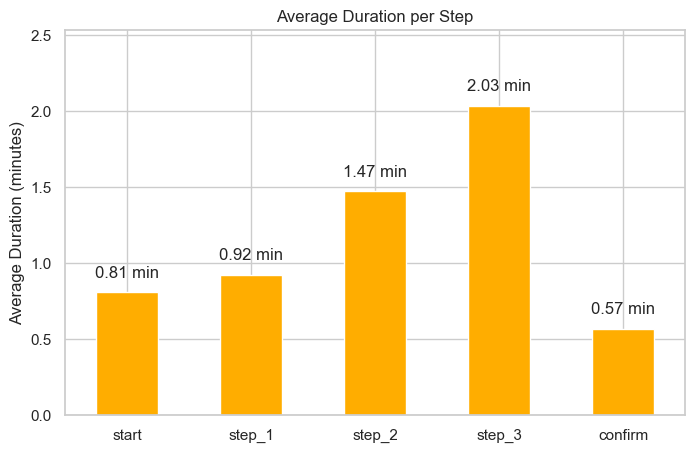

In [503]:
plt.figure(figsize=(8,5))
ax = avg_duration.plot(kind="bar", color="#ffad00")

# Add values on top
for i, v in enumerate(avg_duration):
    ax.text(i, v + 0.1, f"{v:.2f} min", ha="center")

plt.title("Average Duration per Step")
plt.ylabel("Average Duration (minutes)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylim(0, avg_duration.max() + 0.5)
plt.show()

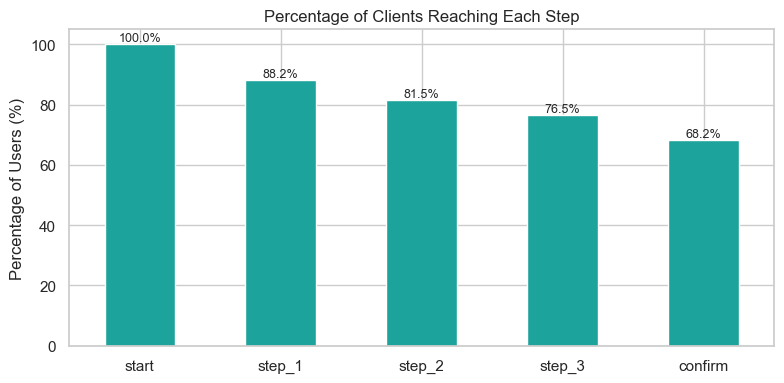

In [446]:
import matplotlib.pyplot as plt

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

# Count unique clients per step
clients_per_step = (
    web.groupby("process_step")["client_id"]
    .nunique()
    .reindex(step_order)
)

# Convert counts to percentage
clients_pct = (clients_per_step / clients_per_step.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(8, 4))

clients_pct.plot(
    kind="bar",
    ax=ax,
    color="#1ca39c",
    edgecolor="white"
)

ax.set_title("Percentage of Clients Reaching Each Step")
ax.set_ylabel("Percentage of Users (%)")
ax.set_xlabel("")
ax.set_xticklabels(step_order, rotation=0)
ax.set_ylim(0, 105)

# Add percentage labels on top
for i, v in enumerate(clients_pct.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()
plt.show()

# Demo dataset exploration and cleaning

In [453]:
#Null values in dema dataset
print("Null counts:")
print(demo.isnull().sum())
print(f"\nNull percentages:")
print((demo.isnull().sum() / len(demo) * 100).round(1))

Null counts:
client_id             0
clnt_tenure_yr       14
clnt_tenure_mnth     14
clnt_age             15
gendr                14
num_accts            14
bal                  14
calls_6_mnth         14
logons_6_mnth        14
age_group           205
dtype: int64

Null percentages:
client_id           0.0
clnt_tenure_yr      0.0
clnt_tenure_mnth    0.0
clnt_age            0.0
gendr               0.0
num_accts           0.0
bal                 0.0
calls_6_mnth        0.0
logons_6_mnth       0.0
age_group           0.3
dtype: float64


In [452]:
demo[demo["age_group"].isna()]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0,NaN
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
69648,5817398,5.0,68.0,14.5,U,3.0,73762.45,1.0,1.0,NaN
69683,778505,13.0,156.0,16.5,M,2.0,15313.57,4.0,4.0,NaN
69872,64420,5.0,66.0,14.5,U,2.0,18408.77,3.0,3.0,NaN
70216,5417612,4.0,59.0,13.5,U,2.0,24435.08,7.0,7.0,NaN


In [530]:
demo.dropna(inplace=True)
#Decided to drop the rows with missing values since they were only 14/15 rows and they were not affecting the overall distribution of the data. 

In [531]:
demo["gendr"].unique()

array(['U', 'M', 'F'], dtype=object)

In [533]:
demo["gendr"].replace({"X": "U"}, inplace=True)

In [534]:
bins = [17, 33, 44, 54, 64, 100]
labels = ["18-34", "35–44", "45-54", "55-64", "65+"]

demo["age_group"] = pd.cut(demo["clnt_age"], bins=bins, labels=labels, include_lowest=True)

In [539]:
# How long the client has been with Vanguard, measured in years.
demo["clnt_tenure_yr"].describe()

count    70404.000000
mean        12.061886
std          6.870492
min          2.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         62.000000
Name: clnt_tenure_yr, dtype: float64

C:\Users\glint\AppData\Local\Temp\ipykernel_27104\1787134737.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tenure = demo.groupby("age_group")["clnt_tenure_yr"].mean().round(1).reset_index()
C:\Users\glint\AppData\Local\Temp\ipykernel_27104\1787134737.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_tenure, x="age_group", y="clnt_tenure_yr", palette="viridis")


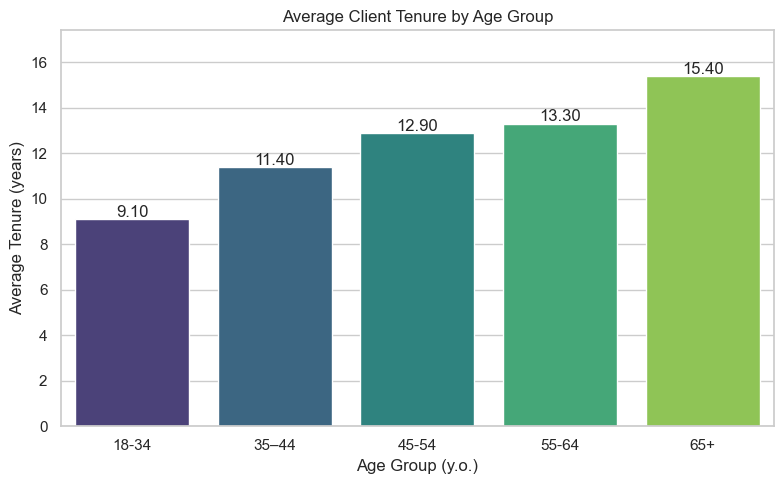

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute average tenure per age group
avg_tenure = demo.groupby("age_group")["clnt_tenure_yr"].mean().round(1).reset_index()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=avg_tenure, x="age_group", y="clnt_tenure_yr", palette="viridis")

# Labels and title
plt.ylabel("Average Tenure (years)")
plt.xlabel("Age Group (y.o.)")
plt.title("Average Client Tenure by Age Group")
plt.xticks(rotation=0)
plt.ylim(0, avg_tenure["clnt_tenure_yr"].max() + 2)

# Add value labels on top
for index, row in avg_tenure.iterrows():
    plt.text(index, row["clnt_tenure_yr"] + 0.1, f'{row["clnt_tenure_yr"]:.2f}', 
             ha='center')

plt.tight_layout()
plt.show()

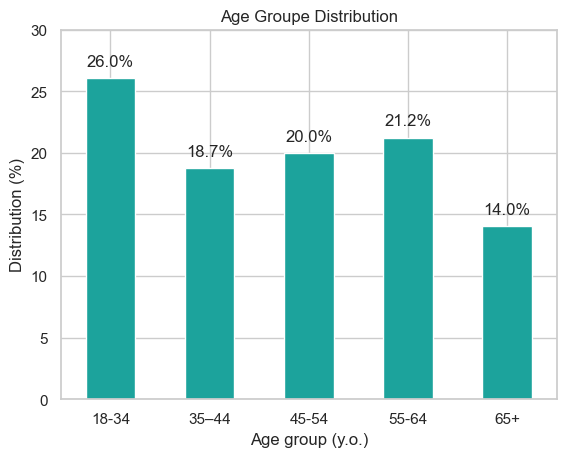

In [535]:
import matplotlib.pyplot as plt

age_pct = (
    demo["age_group"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

ax = age_pct.plot(kind="bar", color="#1ca39c")

for i, v in enumerate(age_pct):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.title("Age Groupe Distribution")
plt.xlabel("Age group (y.o.)")
plt.ylabel("Distribution (%)")
plt.xticks(rotation=0)
plt.ylim(0, 30)
plt.show()

In [536]:
grouped = (
    demo.groupby("age_group")["gendr"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .reset_index().round(1)
)

grouped


C:\Users\glint\AppData\Local\Temp\ipykernel_27104\2522245057.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demo.groupby("age_group")["gendr"]


,age_group,gendr,percentage
0,18-34,U,52.7
1,18-34,M,25.8
2,18-34,F,21.5
3,35–44,M,35.4
4,35–44,F,32.8
5,35–44,U,31.8
6,45-54,F,36.0
7,45-54,M,35.9
8,45-54,U,28.2
9,55-64,F,37.0


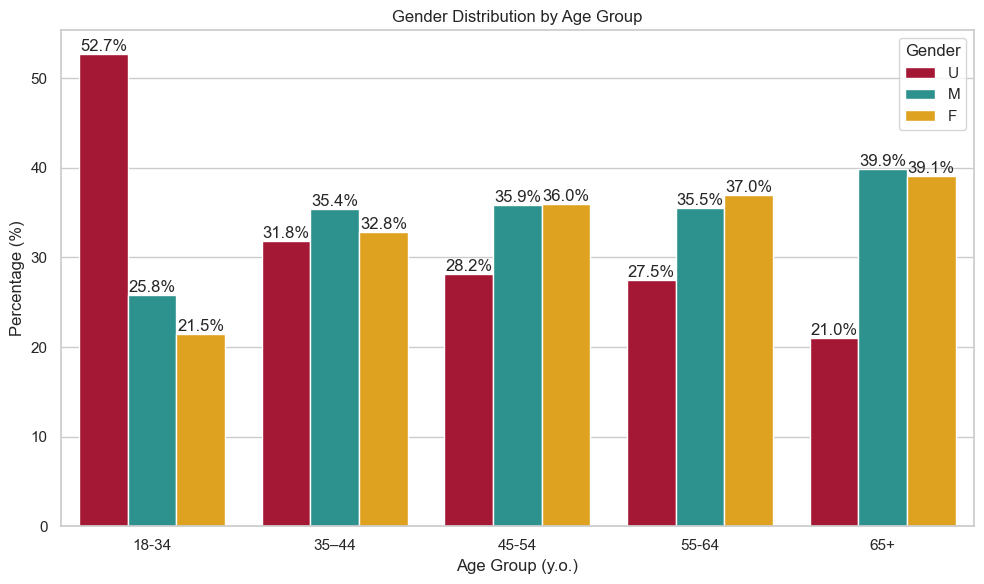

In [537]:
# color="#1ca39c" - green
# color="#ffad00" - yellow
# color="#bc0028" - red
palette = {
    "M": "#1ca39c",   # green
    "F": "#ffad00", # yellow
    "U": "#bc0028"   # red
}

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=grouped,
    x="age_group",
    y="percentage",
    hue="gendr",
    palette=palette
)
ax.legend(title="Gender")
# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge")

plt.ylabel("Percentage (%)")
plt.xlabel("Age Group (y.o.)")
plt.title("Gender Distribution by Age Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [460]:
gendr_percentage=(demo["gendr"].value_counts()/len(demo["gendr"])*100).round(2)
gendr_percentage

gendr
U    34.17
M    33.60
F    32.21
Name: count, dtype: float64

# Web dataset exploration and cleaning

In [517]:
merged_1 = web.merge(
    experiment[["client_id", "variation"]],
    on="client_id",
    how="left"
)
merged_1

,client_id,visitor_id,visit_id,process_step,date_time,step_num,duration,duration_min,variation
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36,1,0 days 00:00:09,0.150000,NaN
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45,2,0 days 00:00:46,0.766667,NaN
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31,3,0 days 00:01:34,1.566667,NaN
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05,4,0 days 00:01:04,1.066667,NaN
4,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09,5,0,0.000000,NaN
...,...,...,...,...,...,...,...,...,...
755400,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:40:08,2,0 days 00:01:20,1.333333,NaN
755401,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:41:28,2,0 days 00:00:19,0.316667,NaN
755402,9999875,738878760_1556639849,931268933_219402947_599432,step_2,2017-06-01 22:41:47,3,0 days 00:03:11,3.183333,NaN
755403,9999875,738878760_1556639849,931268933_219402947_599432,step_3,2017-06-01 22:44:58,4,0 days 00:03:41,3.683333,NaN


In [516]:
merged_1["variation"].fillna("Unknown", inplace=True)

In [509]:
# Size of the Test group in %:
experiment["variation"].value_counts()["Test"]
print((experiment["variation"].value_counts()["Test"].sum() / len(experiment) * 100).round(1))

38.2


In [462]:
# Size of the Control group in %:
experiment["Variation"].value_counts()["Control"]
print((experiment["Variation"].value_counts()["Control"].sum() / len(experiment) * 100).round(1))

33.3


In [ ]:
# Number of complets per step
merged_1["completion"] = (merged_1["duration_min"] > 0).astype(int)

completion = merged_1.pivot_table(
    index="variation",
    columns="step_num",   # 1,2,3,4,5
    values="completion",  # column with 0/1 completion
    aggfunc="count"
)

completion

step_num,1,2,3,4,5
variation,,,,,
Control,47608,29668,25886,22795,17505
Test,56474,38768,30989,25894,25722


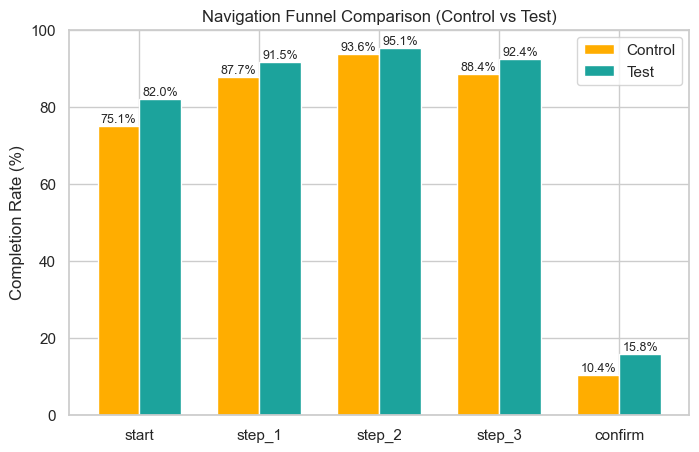

In [511]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure a 0/1 completion column exists
merged_1["completion"] = (merged_1["duration_min"] > 0).astype(int)

# Pivot table: rows = variation, columns = step_num
completion = merged_1.pivot_table(
    index="variation",
    columns="step_num",   # 1,2,3,4,5
    values="completion",  # column with 0/1 completion
    aggfunc="mean"
) * 100  # convert to percent

# Ensure proper order
completion = completion[[1, 2, 3, 4, 5]]
completion = completion.reindex(["Control", "Test"])

# Steps and labels
steps = [1, 2, 3, 4, 5]
step_labels = ["start", "step_1", "step_2", "step_3", "confirm"]
x = np.arange(len(steps))
width = 0.35

# Plot
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, completion.loc["Control"], width, label="Control", color="#ffad00")
ax.bar(x + width/2, completion.loc["Test"], width, label="Test", color="#1ca39c")

# Annotate bars
for i, v in enumerate(completion.loc["Control"]):
    ax.text(i - width/2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
for i, v in enumerate(completion.loc["Test"]):
    ax.text(i + width/2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

# Formatting
ax.set_title("Navigation Funnel Comparison (Control vs Test)")
ax.set_ylabel("Completion Rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(step_labels)
ax.set_ylim(0, 100)
ax.legend()

plt.show()

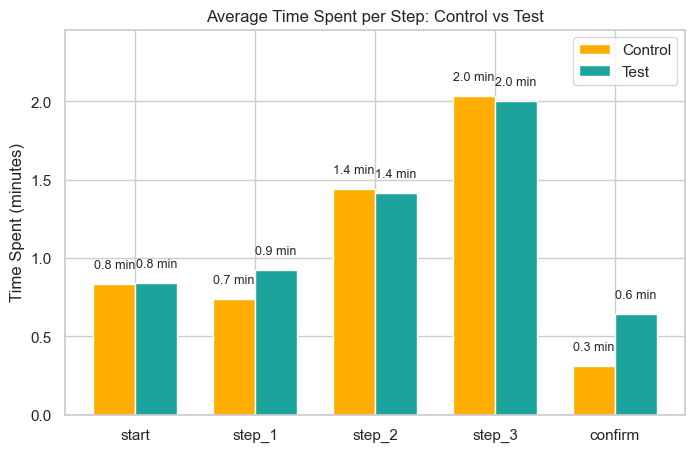

In [512]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure duration_min exists
if "duration_min" not in merged_1.columns:
    merged_1["duration_min"] = merged_1["duration"].dt.total_seconds() / 60

# Average duration per step per variation
avg_duration = merged_1.groupby(["variation", "step_num"])["duration_min"].mean().unstack()
# Ensure steps are in order
avg_duration = avg_duration[[1, 2, 3, 4, 5]]

steps = [1, 2, 3, 4, 5]
step_labels = ["start", "step_1", "step_2", "step_3", "confirm"]
x = np.arange(len(steps))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

# Bars
ax.bar(x - width/2, avg_duration.loc["Control"], width, label="Control", color="#ffad00")
ax.bar(x + width/2, avg_duration.loc["Test"], width, label="Test", color="#1ca39c")

# Annotate bars
for i, v in enumerate(avg_duration.loc["Control"]):
    ax.text(i - width/2, v + 0.1, f"{v:.1f} min", ha="center", fontsize=9)
for i, v in enumerate(avg_duration.loc["Test"]):
    ax.text(i + width/2, v + 0.1, f"{v:.1f} min", ha="center", fontsize=9)

# Formatting
ax.set_title("Average Time Spent per Step: Control vs Test")
ax.set_ylabel("Time Spent (minutes)")
ax.set_xticks(x)
ax.set_xticklabels(step_labels)
ax.set_ylim(0, avg_duration.values.max() * 1.2)
ax.legend()

plt.show()

In [ ]:
grouped = merged.groupby("variation").agg({
    "clnt_age": ["mean", "median"],
    "num_accts": ["mean"],
    "clnt_tenure_yr": ["mean"],
    "gendr": lambda x: x.value_counts().to_dict()
})
grouped

clnt_age        num_accts clnt_tenure_yr  \
                mean median      mean           mean   
variation                                              
Control    48.693175   50.0  2.281199      12.343611   
Test       48.585171   50.0  2.271041      12.340764   

                                          gendr  
                                       <lambda>  
variation                                        
Control    {'M': 11094, 'U': 10699, 'F': 10444}  
Test       {'M': 12661, 'U': 12334, 'F': 12195}

In [ ]:
counts = merged["variation"].value_counts()
print(counts)

variation
Test       37204
Control    32243
Name: count, dtype: int64


In [ ]:
variance_percentage = (
    merged["variation"]
    .value_counts(normalize=True) * 100
).round(2)

variance_percentage

variation
Test       53.57
Control    46.43
Name: proportion, dtype: float64

# Calculate the Error Rate

In [546]:
# Calculate the Error Rate:
import pandas as pd

# Make sure data is sorted by client and timestamp
merged_1 = merged_1.sort_values(["client_id", "date_time"])

# Identify errors per row
merged_1["error"] = merged_1.groupby("client_id")["step_num"].diff() < 0

# Convert True/False to 1/0
merged_1["error"] = merged_1["error"].fillna(False).astype(int)

# Check total errors
total_errors = merged_1["error"].sum()
total_rows = merged_1.shape[0]
error_rate = total_errors / total_rows * 100

print(f"Total errors: {total_errors}")
print(f"Error rate: {error_rate:.2f}%")

Total errors: 75059
Error rate: 9.94%


In [ ]:
# Error rate per step: Gives % of users making an error at each step.
error_per_step = merged_1.groupby("step_num")["error"].mean() * 100
print(error_per_step)

step_num
1    20.813298
2     8.918275
3     7.121492
4     0.228079
5     0.000000
Name: error, dtype: float64


In [548]:
# Error rate per variation
# diff() calculates difference with the previous step per client.
# If a user stays on the same step, it’s not an error.
# This method ignores missing steps (NaN in step_num).
error_per_variation = merged_1.groupby("variation")["error"].mean() * 100
print(error_per_variation)

variation
Control     9.295144
Test       10.732821
Name: error, dtype: float64


In [549]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure data is sorted
merged_1 = merged_1.sort_values(["client_id", "date_time"])

# Create error column: step goes backwards = error
merged_1["error"] = merged_1.groupby("client_id")["step_num"].diff() < 0
merged_1["error"] = merged_1["error"].fillna(False).astype(int)

# Calculate error rate per step and variation
error_rates = (
    merged_1.groupby(["variation", "step_num"])["error"]
    .mean()   # mean gives fraction of errors
    .reset_index()
)
error_rates["error_rate_pct"] = error_rates["error"] * 100  # convert to %

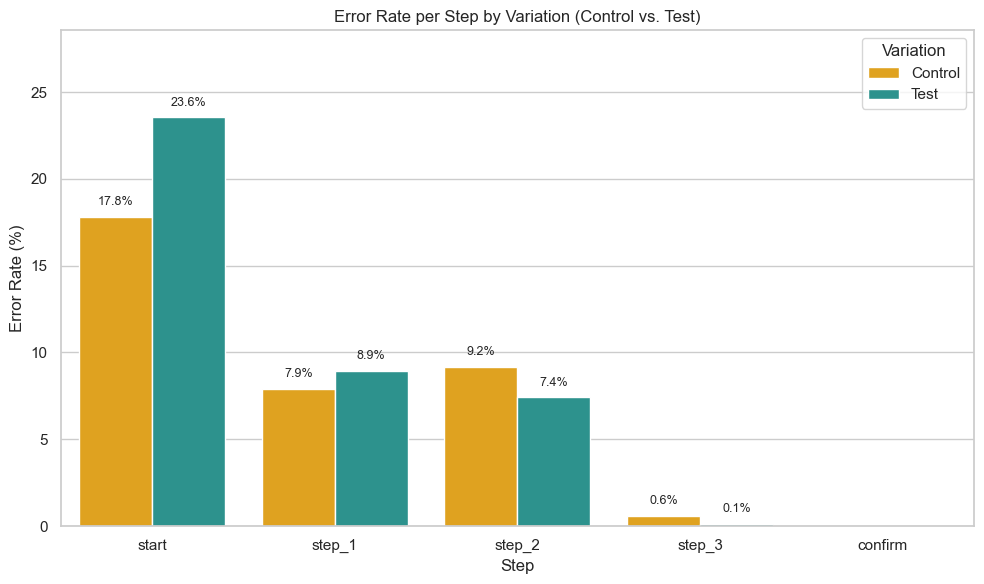

In [556]:
plt.figure(figsize=(10,6))

# Draw the barplot
ax = sns.barplot(
    data=error_rates,
    x="step_num",
    y="error_rate_pct",
    hue="variation",
    palette=["#ffad00", "#1ca39c"]
)

# Labels and title
ax.set_ylabel("Error Rate (%)")
ax.set_xlabel("Step")
ax.set_title("Error Rate per Step by Variation (Control vs. Test)")
ax.set_xticks(np.arange(len(steps)))
ax.set_xticklabels(step_labels)
ax.set_ylim(0, error_rates["error_rate_pct"].max() + 5)

# Add value labels on top of each bar, skip bars with height 0
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Only annotate non-zero bars
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height + 0.5),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.legend(title="Variation")
plt.tight_layout()
plt.show()

#### Calculate the Error Rate per Age Group and Variation

In [563]:
merged_2 = demo.merge(merged_1, on="client_id", how="inner")

merged_2.columns = merged_2.columns.str.strip().str.lower().str.replace(" ", "_")

merged_2.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,visitor_id,visit_id,process_step,date_time,step_num,duration,duration_min,variation,completion,error
0,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,427070339_1413275162,104438405_2368283624_817211,start,2017-03-29 10:58:35,1,0 days 00:01:08,1.133333,Test,1,0
1,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,427070339_1413275162,104438405_2368283624_817211,start,2017-03-29 10:59:43,1,0 days 00:01:57,1.950000,Test,1,0
2,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,427070339_1413275162,104438405_2368283624_817211,start,2017-03-29 11:01:40,1,0 days 00:01:04,1.066667,Test,1,0
3,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,427070339_1413275162,104438405_2368283624_817211,start,2017-03-29 11:02:44,1,0,0.000000,Test,0,0
4,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,427070339_1413275162,228976764_46825473280_96584,start,2017-04-02 11:21:28,1,0 days 00:00:10,0.166667,Test,1,0


In [564]:
merged_2.drop(columns=["clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "gendr", "bal","num_accts", "calls_6_mnth", "logons_6_mnth"], inplace=True)
merged_2.head()

,client_id,age_group,visitor_id,visit_id,process_step,date_time,step_num,duration,duration_min,variation,completion,error
0,836976,55-64,427070339_1413275162,104438405_2368283624_817211,start,2017-03-29 10:58:35,1,0 days 00:01:08,1.133333,Test,1,0
1,836976,55-64,427070339_1413275162,104438405_2368283624_817211,start,2017-03-29 10:59:43,1,0 days 00:01:57,1.950000,Test,1,0
2,836976,55-64,427070339_1413275162,104438405_2368283624_817211,start,2017-03-29 11:01:40,1,0 days 00:01:04,1.066667,Test,1,0
3,836976,55-64,427070339_1413275162,104438405_2368283624_817211,start,2017-03-29 11:02:44,1,0,0.000000,Test,0,0
4,836976,55-64,427070339_1413275162,228976764_46825473280_96584,start,2017-04-02 11:21:28,1,0 days 00:00:10,0.166667,Test,1,0


In [565]:
# Sort by client and timestamp
merged_2 = merged_2.sort_values(["client_id", "date_time"])

# Create error column: step goes backward = 1, else 0
merged_2["error"] = merged_2.groupby("client_id")["step_num"].diff() < 0
merged_2["error"] = merged_2["error"].fillna(False).astype(int)

In [566]:
# Group by age_group and variation
error_by_age = (
    merged_2.groupby(["age_group", "variation"])["error"]
    .mean()  # fraction of errors
    .reset_index()
)

# Convert fraction to percentage
error_by_age["error_rate_pct"] = error_by_age["error"] * 100

print(error_by_age)

  age_group variation     error  error_rate_pct
0     18-34   Control  0.083483        8.348275
1     18-34      Test  0.084299        8.429945
2     35–44   Control  0.079479        7.947914
3     35–44      Test  0.083273        8.327278
4     45-54   Control  0.089222        8.922160
5     45-54      Test  0.107267       10.726694
6     55-64   Control  0.100600       10.060028
7     55-64      Test  0.122338       12.233839
8       65+   Control  0.113570       11.356999
9       65+      Test  0.138900       13.890019


C:\Users\glint\AppData\Local\Temp\ipykernel_27104\1891735956.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_2.groupby(["age_group", "variation"])["error"]


In [567]:
error_by_age_pivot = error_by_age.pivot(index="age_group", columns="variation", values="error_rate_pct")
print(error_by_age_pivot)

variation    Control       Test
age_group                      
18-34       8.348275   8.429945
35–44       7.947914   8.327278
45-54       8.922160  10.726694
55-64      10.060028  12.233839
65+        11.356999  13.890019


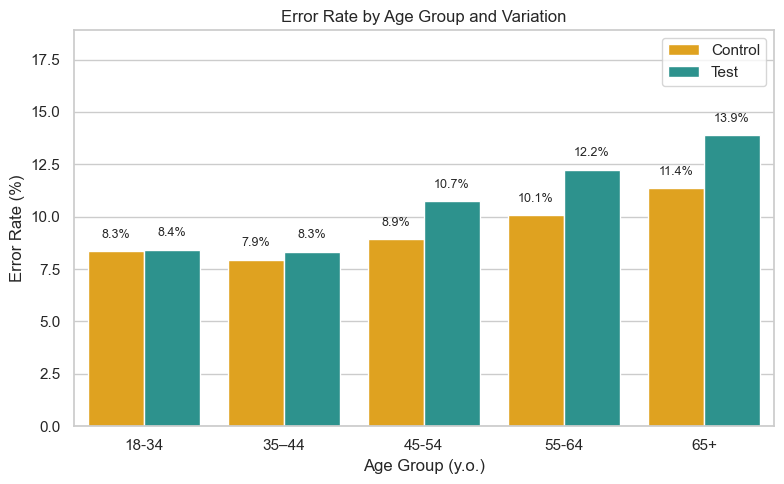

In [574]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=error_by_age,
    x="age_group",
    y="error_rate_pct",
    hue="variation",
    palette=["#ffad00", "#1ca39c"]
)

# Labels
ax.set_ylabel("Error Rate (%)")
ax.set_xlabel("Age Group (y.o.)")
ax.set_title("Error Rate by Age Group and Variation")
ax.set_ylim(0, error_by_age["error_rate_pct"].max() + 5)
ax.legend(title=None)

# Add value labels on top
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width()/2., height + 0.5),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()